# STATE Training on Replogle-Nadig

This notebook walks you through training the STATE Transition (ST) model for context generalization. The notebook trains ST on the Replogle-Nadig dataset<sup>[1,2]</sup>, holding out a subset of perturbations in **hepg2** celltype.

The objective of this notebook is to demonstrate how to download the dataset from the cited sources, preprocess them and train a model. The notebook aims to follow the same steps as used in the [preprint](https://www.google.com/url?q=https%3A%2F%2Fwww.biorxiv.org%2Fcontent%2F10.1101%2F2025.06.26.661135).

#### References:
[1] J. M. Replogle, R. A. Saunders, A. N. Pogson, J. A. Hussmann, A. Lenail, A. Guna, L. Mascibroda, E. J. Wagner, K. Adelman, G. Lithwick-Yanai, et al. Mapping information-rich genotype-phenotype landscapes with genome-scale perturb-seq. Cell, 185(14):2559–2575, 2022. doi: [https://doi.org/10.1016/j.cell.2022.05.013](https://doi.org/10.1016/j.cell.2022.05.013)


[2] Nadig, A., Replogle, J.M., Pogson, A.N. et al. Transcriptome-wide analysis of differential expression in perturbation atlases. Nat Genet 57, 1228–1237 (2025). doi: [https://doi.org/10.1038/s41588-025-02169-3](https://doi.org/10.1038/s41588-025-02169-3)

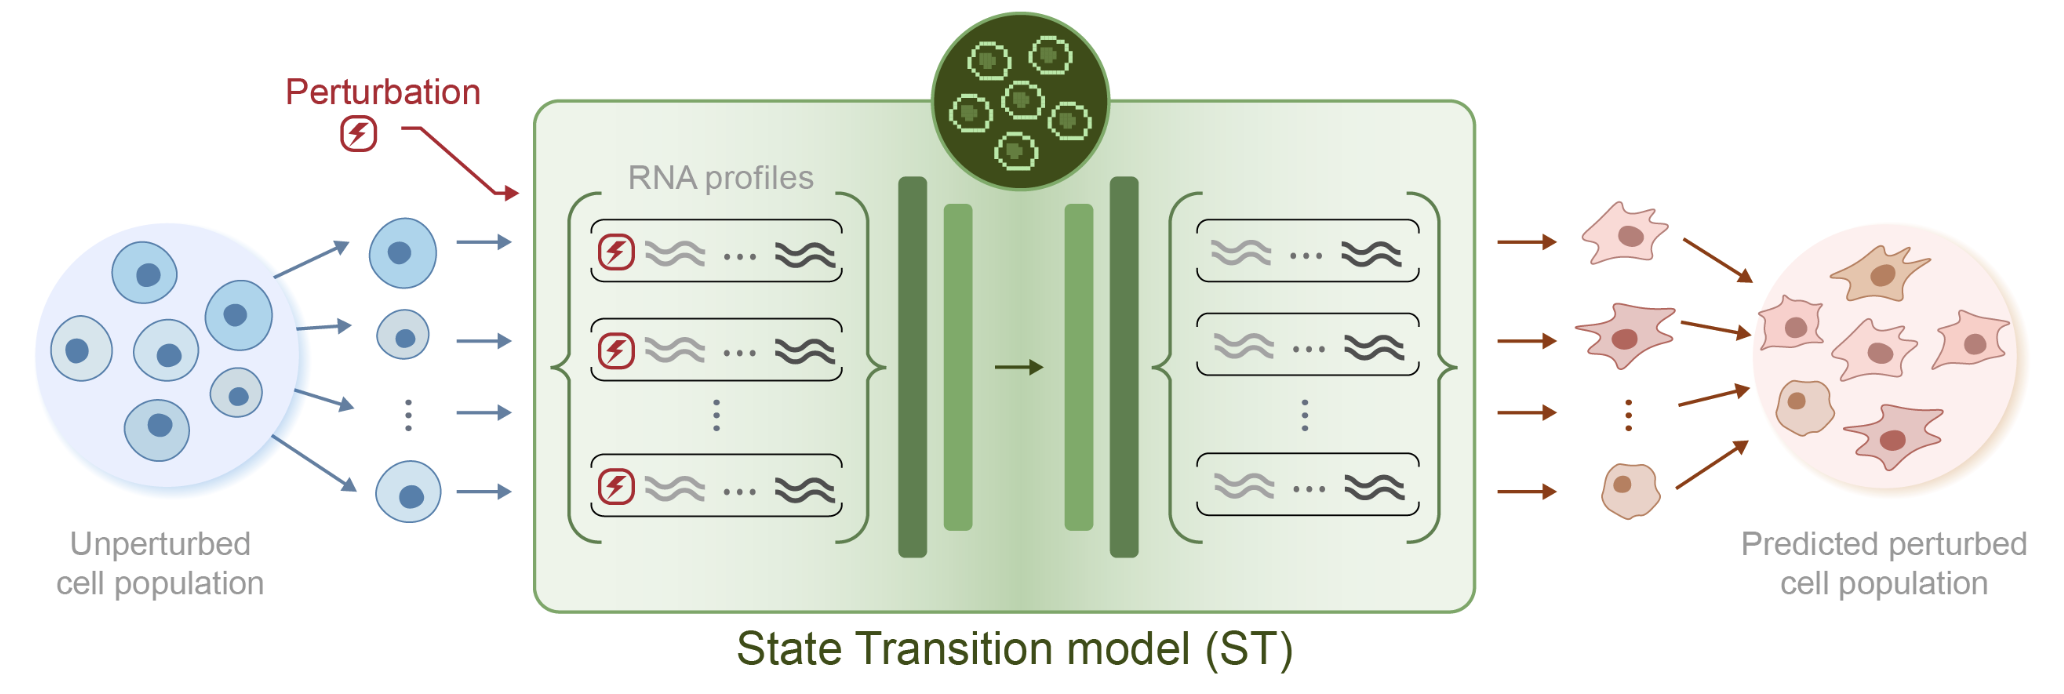

In [1]:
! pip install scanpy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.3/186.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 132.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

# Clone the repository

In [2]:
# Clone the repository
! git clone https://github.com/ArcInstitute/state.git
%cd state

# Colab-specific config for pytorch lightning
import os
os.environ['MPLBACKEND'] = 'Agg'

Cloning into 'state'...
remote: Enumerating objects: 9249, done.
remote: Counting objects: 100% (2289/2289), done.
remote: Compressing objects: 100% (521/521), done.
remote: Total 9249 (delta 2024), reused 1786 (delta 1757), pack-reused 6960 (from 4)
Receiving objects: 100% (9249/9249), 126.35 MiB | 32.38 MiB/s, done.
Resolving deltas: 100% (5813/5813), done.
/content/state


In [1]:
%cd state

/content/state


In [2]:
import os
os.environ['MPLBACKEND'] = 'Agg'

# Download the Replogle dataset

Downloading from data sources listed in the cited references.

In [3]:
from huggingface_hub import snapshot_download
import os

# Define the repository ID and the local directory to save the files
repo_id = "arcinstitute/Replogle-Nadig-Preprint"
local_dir = "/content/data"

# Create the local directory if it doesn't exist
os.makedirs(local_dir, exist_ok=True)

# Download everything except the concatenated file
snapshot_download(
    repo_id=repo_id,
    repo_type="dataset",
    local_dir=local_dir,
    local_dir_use_symlinks=False,
    ignore_patterns=["replogle.h5ad"],
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/content/data'

# Run Data Preprocessing in this Colab

In [4]:
! uvx -q --from git+https://github.com/ArcInstitute/cell-load.git@cli_run_uv filter_on_target_knockdown --help

usage: filter_on_target_knockdown [-h] -o OUTPUT
                                  [--perturbation-column PERTURBATION_COLUMN]
                                  [--control-label CONTROL_LABEL]
                                  [--residual-expression RESIDUAL_EXPRESSION]
                                  [--cell-residual-expression CELL_RESIDUAL_EXPRESSION]
                                  [--min-cells MIN_CELLS] [--layer LAYER]
                                  [--var-gene-name VAR_GENE_NAME]
                                  [--preprocess]
                                  input

Filter cells based on on-target knockdown criteria

positional arguments:
  input                 Path to input AnnData file (.h5ad)

options:
  -h, --help            show this help message and exit
  -o OUTPUT, --output OUTPUT
                        Path to output AnnData file (.h5ad)
  --perturbation-column PERTURBATION_COLUMN
                        Column in adata.obs holding perturbation identities
   

In [3]:
from huggingface_hub import snapshot_download
import os

In [9]:
adata.var

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000228794,LINC01128,chr1,825138,868202,gene_version9,+,43064,True,0.187369,0.462334,2.467510,1.140814
ENSG00000188976,NOC2L,chr1,944203,959309,gene_version11,-,15106,True,1.742970,1.967864,1.129029,2.221775
ENSG00000187583,PLEKHN1,chr1,966482,975865,gene_version11,+,9383,True,0.164274,0.444831,2.707855,1.204539
ENSG00000188290,HES4,chr1,998962,1000172,gene_version10,-,1210,True,2.179681,2.977747,1.366139,4.068017
ENSG00000187608,ISG15,chr1,1001138,1014540,gene_version10,+,13402,True,1.701508,4.689206,2.755911,12.923033
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198786,MT-ND5,chrM,12337,14148,gene_version2,+,1811,True,36.606468,28.708439,0.784245,22.514448
ENSG00000198695,MT-ND6,chrM,14149,14673,gene_version2,-,524,True,4.300245,4.671066,1.086233,5.073864
ENSG00000198727,MT-CYB,chrM,14747,15887,gene_version2,+,1140,True,143.382690,102.631416,0.715787,73.462204


In [15]:
file_path

'/content/data/GSE264667_hepg2_raw_singlecell_01.h5ad'

In [18]:
import anndata as ad
import glob
import os

data_dir = "/content/data"
h5ad_files = glob.glob(os.path.join(data_dir, "*.h5ad"))

for file_path in h5ad_files:
    # Skip files that might have been created as outputs
    if file_path.endswith("_filtered.h5ad"):
        continue

    print(f"Checking {file_path}...")
    adata = ad.read_h5ad(file_path)


    # Make index unique if it isn't already
    #if not adata.var_names.is_unique:
    print(f"  -> Duplicates found! Making var_names unique...")
    adata.var_names = adata.var['gene_name'].astype(str)
    adata.var_names_make_unique()
    adata.var['gene_name'] = adata.var_names

    adata.write_h5ad(file_path)
    print(f"  -> Saved updated file.")
    #else:
        #print(f"  -> var_names are already unique.")


Checking /content/data/rpe1_normalized_singlecell_01.h5ad...
  -> Duplicates found! Making var_names unique...
  -> Saved updated file.
Checking /content/data/K562_essential_normalized_singlecell_01.h5ad...
  -> Duplicates found! Making var_names unique...
  -> Saved updated file.
Checking /content/data/GSE264667_jurkat_raw_singlecell_01.h5ad...
  -> Duplicates found! Making var_names unique...
  -> Saved updated file.
Checking /content/data/GSE264667_hepg2_raw_singlecell_01.h5ad...
  -> Duplicates found! Making var_names unique...
  -> Saved updated file.


In [14]:
ls /content/data/*.h5ad

/content/data/GSE264667_hepg2_raw_singlecell_01.h5ad
/content/data/GSE264667_jurkat_raw_singlecell_01.h5ad
/content/data/K562_essential_normalized_singlecell_01.h5ad
/content/data/rpe1_normalized_singlecell_01.h5ad


In [19]:
# @title Filter the perturbations for knockdown efficacy, and preprocess the data as in the state paper. Note you need high-memory setting in the colab, or this will crash.

%%bash
set -euo pipefail
shopt -s nullglob

for f in /content/data/*.h5ad; do
  [[ "$f" == *_filtered.h5ad ]] && continue
  out="${f%.h5ad}_filtered.h5ad"
  echo "Processing: $f -> $out"
  uvx -q --from git+https://github.com/ArcInstitute/cell-load.git@main filter_on_target_knockdown \
    --perturbation-column "gene" \
    --control-label "non-targeting" \
    --output "$out" \
    --preprocess \
    "$f"
done

echo "Done. Filtered files:"
ls -1 /content/data/*_filtered.h5ad

Processing: /content/data/GSE264667_hepg2_raw_singlecell_01.h5ad -> /content/data/GSE264667_hepg2_raw_singlecell_01_filtered.h5ad
Loading data from /content/data/GSE264667_hepg2_raw_singlecell_01.h5ad...
Loaded AnnData with 145473 cells and 9624 genes
Applying on-target knockdown filter...
Filtered to 96616 cells and 9624 genes
Applying state paper preprocessing...
  - Normalizing to 10k read depth...
  - Log transforming...
Saving filtered data to /content/data/GSE264667_hepg2_raw_singlecell_01_filtered.h5ad...
Done!
Processing: /content/data/GSE264667_jurkat_raw_singlecell_01.h5ad -> /content/data/GSE264667_jurkat_raw_singlecell_01_filtered.h5ad
Loading data from /content/data/GSE264667_jurkat_raw_singlecell_01.h5ad...
Loaded AnnData with 262956 cells and 8882 genes
Applying on-target knockdown filter...
Filtered to 184470 cells and 8882 genes
Applying state paper preprocessing...
  - Normalizing to 10k read depth...
  - Log transforming...
Saving filtered data to /content/data/GSE26

In [20]:
# @title Concatenate the data and compute HVGs (memory intensive for a Colab).
import scanpy as sc
import anndata as ad
import numpy as np
from scipy import sparse

# Load filtered files
files = [
    '/content/data/GSE264667_hepg2_raw_singlecell_01_filtered.h5ad',
    '/content/data/GSE264667_jurkat_raw_singlecell_01_filtered.h5ad',
    '/content/data/K562_essential_normalized_singlecell_01_filtered.h5ad',
    '/content/data/rpe1_normalized_singlecell_01_filtered.h5ad'
]

adatas = [ad.read_h5ad(f) for f in files]

# Concatenate with inner join on columns
x = ad.concat(adatas, join='inner')

# Make obs names unique
x.obs_names_make_unique()

# Compute top 2000 HVGs (data is already log-transformed)
sc.pp.highly_variable_genes(x, n_top_genes=2000)

# Set X_hvg obsm key
hvg_data = x.X[:, x.var['highly_variable']]
if sparse.issparse(hvg_data):
    hvg_data = hvg_data.toarray()
x.obsm['X_hvg'] = hvg_data

# Write output
x.write('/content/processed_data/replogle.h5ad')

/tmp/ipykernel_6105/2681153919.py:18: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  x = ad.concat(adatas, join='inner')


FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = '/content/processed_data/replogle.h5ad', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

# Alternatively, download from Hugging Face.

In [21]:
# @title Download the output of the above section directly.

from huggingface_hub import snapshot_download
import os

repo_id = "arcinstitute/Replogle-Nadig-Preprint"
local_dir = "/content/processed_data"
os.makedirs(local_dir, exist_ok=True)

# Download ONLY the specified file
snapshot_download(
    repo_id=repo_id,
    repo_type="dataset",
    local_dir=local_dir,
    local_dir_use_symlinks=False,          # optional: copy files instead of symlinks
    allow_patterns=["replogle.h5ad"],  # restrict to just this file
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

'/content/processed_data'

# Creating a TOML file for training

For this demonstration, we hold out a subset of perturbations from the cell type **hepg2** for validation and testing. We can precisely control which cell types and perturbations to holdout using a TOML file.

For zero-shot generalization across cellular contexts, we can add the cell types under the *zeroshot* label. In this demonstration, as in the [preprint](https://www.google.com/url?q=https%3A%2F%2Fwww.google.com%2Furl%3Fq%3Dhttps%253A%252F%252Fwww.biorxiv.org%252Fcontent%252F10.1101%252F2025.06.26.661135), we perform few-shot generalization, by holding out a subset of perturbations from the cell type to create the val and test set.

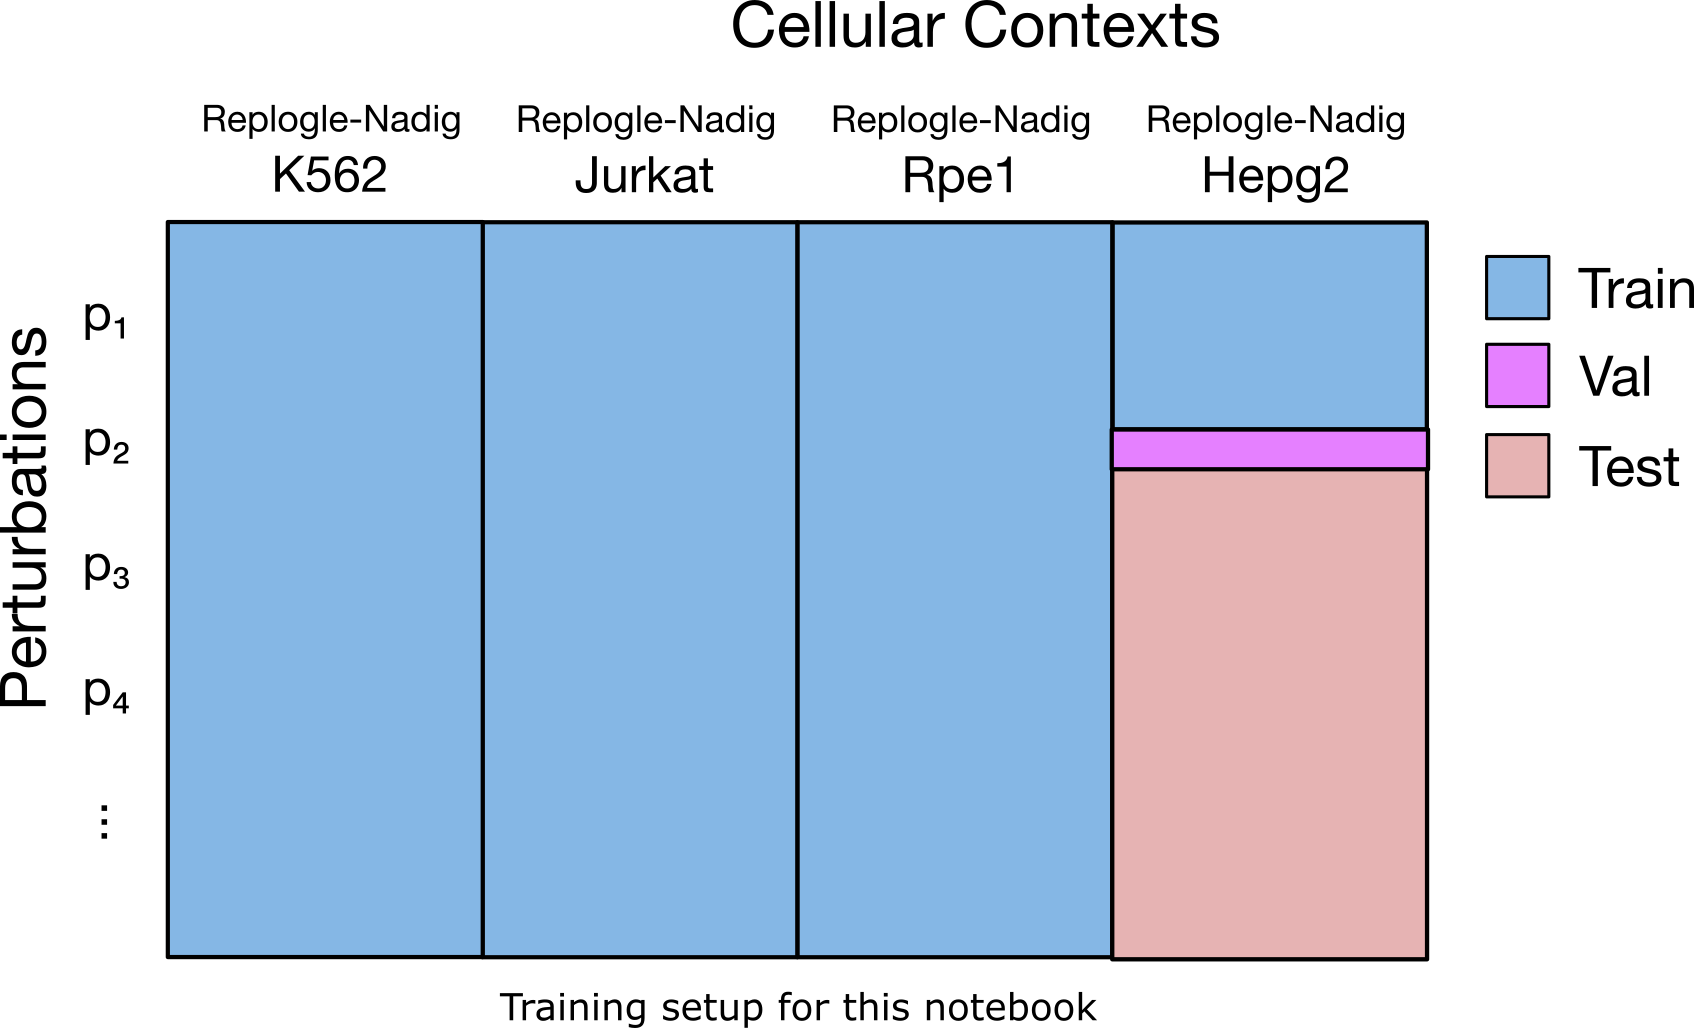

In [22]:
! pip install toml -q

import toml

config = {
    # Dataset paths - maps dataset names to their directories
    "datasets": {
        "replogle_proper": "/content/processed_data"
    },
    # Training specifications
    # All cell types in a dataset automatically go into training (excluding zeroshot/fewshot overrides)
    "training": {
        "replogle_proper": "train"
    },
    # Zeroshot specifications - entire cell types go to val or test
    "zeroshot": {},
    # Fewshot specifications - explicit perturbation lists
    "fewshot": {
        "replogle_proper.hepg2": {
            "val": [
                'ATP6V1G1', 'TSEN34', 'TRAPPC8', 'NDUFS3', 'MRPS24', 'DNTTIP2',
                'WDR77', 'DHX36', 'RTCB', 'RPA3', 'CCDC144NL', 'NFKBIE', 'NFRKB',
                'TRMT10C', 'DIS3', 'CEP85', 'USP37', 'NPLOC4', 'UCHL5', 'NUP85',
                'DCTN1', 'GINS4', 'ZNF317', 'OR2T29', 'ZCCHC9', 'ALG11', 'PSMG4',
                'TUBD1', 'NDC1', 'HYPK', 'NASP', 'POLR3K', 'DESI1', 'TRAIP', 'ASCC3',
                'HCRTR1', 'ZW10', 'MIS12', 'LAMTOR4', 'PABPC4', 'NDUFA3', 'STAT5B',
                'PRDM4', 'GEMIN8', 'TRNP1', 'LCE1E', 'TP53RK', 'HNRNPH1', 'CYREN',
                'SMC2', 'TAF5', 'CABIN1', 'DCTN6', 'PPAN', 'GNL3', 'SMN2', 'NAA10',
                'THAP1', 'NOC4L', 'ZC3H4', 'C9orf78', 'SDHA', 'TERF2', 'RFC4', 'PEF1',
                'SRSF7', 'CRKL', 'INTS13', 'GCOM1', 'LTBP4', 'OR4N2', 'ZWINT', 'SNIP1',
                'HIST2H3D', 'DERL2', 'ANAPC1', 'POLR2G', 'E4F1', 'CWF19L2', 'MRGBP', 'SPG7',
                'CHMP5', 'CCDC115', 'ACD', 'HMGCS1', 'DNM1', 'NOL10', 'ZNF559', 'ZNF763',
                'XRCC3', 'NSF', 'SUPT5H', 'SLC1A5', 'MRPL36', 'RNMT', 'SNAPC1', 'CSNK2B',
                'KANSL2', 'PEX1', 'PITRM1', 'SPATA5', 'RPN1', 'CD8B', 'PSMD9'
            ],
            "test": [
                'TTF2', 'INO80B', 'ALG14', 'SNRNP27', 'MRPS14', 'UNCX', 'HUWE1', 'KAT7',
                'DIMT1', 'TCP1', 'DENR', 'NSRP1', 'VPS18', 'SRP19', 'CCDC86', 'SPOUT1',
                'CARF', 'VPS13D', 'UQCRFS1', 'LPIN1', 'PLK4', 'PRC1', 'ECT2', 'PTPN11',
                'CPSF1', 'PDCD5', 'TRAPPC1', 'PPWD1', 'DUT', 'EFR3A', 'LAMTOR3', 'GCLC',
                'MCM4', 'NHLRC2', 'WDR92', 'LENG8', 'SRP14', 'POLE2', 'KCNA10', 'RPL7L1',
                'FAM133B', 'ZNF676', 'COPS3', 'SMC5', 'HAUS1', 'CCDC78', 'NSUN4', 'ZNHIT6',
                'CCDC6', 'WDTC1', 'KDM5C', 'NLE1', 'NBPF15', 'WDR46', 'TPI1', 'SUGP1',
                'RABGGTA', 'MRPL9', 'GINS3', 'CCDC137', 'ZNF468', 'TIGD1', 'NOP2', 'MED26',
                'AKIRIN2', 'MRPL3', 'MED14', 'ATP6V1D', 'GPN3', 'MED7', 'ISCA2', 'RBM10',
                'TBCA', 'TMEM199', 'HEXIM1', 'RPL29', 'INTS3', 'RPS5', 'SF3A3', 'THOC1',
                'OPA1', 'INPPL1', 'ERAL1', 'COX15', 'SET', 'BRCA2', 'RANGAP1', 'RPL23A',
                'SUPT16H', 'LAMB1', 'UBQLN4', 'TBL3', 'TRMT6', 'C14orf178', 'CLP1', 'RPL35',
                'RPS25', 'CPSF2', 'SPAG7', 'RFC2', 'CENPC', 'RPL7', 'FNTA', 'TAF13', 'SNAPC5',
                'MRPS11', 'MEMO1', 'PGS1', 'HIST1H2AB', 'EPS8L1', 'TEFM', 'GNPNAT1', 'HNRNPDL',
                'TINF2', 'PCM1', 'ZNF492', 'PC', 'MRPS23', 'GMPPB', 'TMEM161B', 'EXOSC5',
                'PRPF39', 'SRP72', 'NOL11', 'RPS2', 'XPO5', 'SETX', 'GSPT1', 'AP2S1', 'SF1',
                'ZFP69B', 'TPRKB', 'TTC4', 'REXO2', 'RNF8', 'MRPL24', 'DDX47', 'PAM16', 'EMC4',
                'MASTL', 'KDM6A', 'PTPN23', 'AIFM1', 'GTF2H2', 'ARL4D', 'COG6', 'RPAP2', 'CWC15',
                'EIF1AX', 'EIF2S1', 'DCUN1D5', 'RCL1', 'ZBTB4', 'ALG1L', 'RPIA', 'GPS1', 'HAUS6',
                'NKAP', 'PTMA', 'ARHGAP11B', 'GMPS', 'USP10', 'NDC80', 'TMX2', 'SNRNP48', 'MRPL2',
                'CEP192', 'CACTIN', 'CDC6', 'CDC42', 'GLE1', 'RNPC3', 'CD2BP2', 'PPP4C', 'SP2',
                'CCDC59', 'CBLL1', 'USP14', 'ISG20L2', 'ZNF787', 'NUDCD3', 'NOL9', 'RFC1', 'GTF2B',
                'DDX52', 'ZBTB17', 'OGT', 'SKP1', 'POGZ', 'SEPSECS', 'BTAF1', 'HARS', 'SDE2', 'CEP68',
                'RARS', 'SRSF10', 'KDM1A', 'NDUFA6', 'NELFA', 'NOMO3', 'TUFM', 'SLU7', 'SPATA5L1',
                'ZNF506', 'FBLIM1', 'CDK9', 'SLC16A5', 'RFFL', 'PRRC2A', 'RAC1', 'COTL1', 'ARPC4',
                'DAD1', 'SMNDC1', 'ATP6V1E1', 'VPS29', 'ZNHIT3', 'FYN', 'NUTF2', 'SKP2', 'ZNF407',
                'MED29', 'U2SURP', 'GSK3B', 'HIST1H2AE', 'UTP6', 'GTF2H4', 'CLCC1', 'SNF8', 'UTP15',
                'DNAJC11', 'RAB6A', 'TMEM240', 'ITGB1BP1', 'BYSL', 'CDAN1', 'MIPEP', 'DHX16', 'HDAC3',
                'SMG7', 'CHMP1A', 'FAU', 'MRPL13', 'CCP110', 'TARS2', 'DDX24', 'MYB', 'TTK', 'BCAR1',
                'RPP21', 'ERVW-1', 'SMAGP', 'MED19', 'HIST1H2BJ', 'SRRM2', 'GTF3C6', 'ZC3H13', 'PPP1R11',
                'CMTR2', 'QRSL1', 'RPL26', 'EIF2B1', 'MOK', 'NUB1', 'E2F6', 'PFDN1', 'NOL7', 'TFRC',
                'CMTR1', 'UBA2', 'MTREX', 'HINFP', 'MVD', 'NELFE', 'PDCD7', 'WBP1', 'SMG8', 'GET3',
                'OR4K1', 'RPP14', 'COG3', 'PELP1', 'C1D', 'TFB1M', 'MRPS16', 'RBM42', 'HIST2H2AA3',
                'NOL6', 'ZDHHC7', 'DDX20', 'SEC61G', 'CHMP3', 'VARS2', 'RPS21', 'TNNT2', 'CCDC144A',
                'YJEFN3', 'MAT2A', 'GSDMA', 'TXN', 'MEN1', 'ATP6V1F', 'NCAPD2', 'CS', 'MED1', 'MRPS22',
                'NVL', 'BRIX1', 'MOCS3', 'EMC1', 'POTEI', 'SSBP1', 'TULP1', 'AGBL5', 'PAXBP1', 'IARS2',
                'LAS1L', 'CT45A5', 'SOD2', 'SDHC', 'GTF2H3', 'UBAP1', 'PDRG1', 'INTS12', 'PAK1IP1',
                'MTCP1', 'RPS26', 'ZC3H18', 'WARS', 'RUVBL2', 'KRTAP4-2', 'NBPF12', 'ANAPC5', 'OSTC',
                'GPN2', 'HMGB3', 'POU5F1B', 'RPL28', 'CNOT2', 'EIF3F', 'MRPL39', 'PGK1', 'PDCD2',
                'NCBP1', 'MDN1', 'MRM1', 'ABHD11', 'GART', 'CENPN', 'MT2A', 'FGFR1OP', 'AARS2',
                'INTS10', 'MED9', 'HSD17B10', 'RRM1', 'DNM1L', 'COMTD1', 'SRFBP1', 'ADNP2', 'ZNF335',
                'AHCY', 'UBE2N', 'CUL1', 'ANKRD49', 'C7orf26', 'TBC1D3', 'TXNL4B', 'PES1', 'CPSF3',
                'DNAJA1', 'CNOT3', 'MARS2', 'PPIL2', 'CCND1', 'UTP11', 'TMEM214', 'NDUFB4', 'RPL26L1',
                'ZC3H8', 'MAU2', 'PRDM8', 'CENPT', 'SYF2', 'NDOR1', 'TADA1', 'CSNK1A1', 'GAR1', 'ORC5',
                'PIAS1', 'HSPD1', 'MED12', 'RMI1', 'ACTR8', 'DDX27', 'EIF2S3', 'ARHGAP6', 'MSL1',
                'CNOT11', 'COX17', 'COPS2', 'PRELID3B', 'TOX4', 'DDX18', 'URB1', 'WDHD1', 'TIMELESS',
                'TAF6', 'CHCHD4', 'RPS8', 'CDC20', 'IFITM3', 'TUBGCP3', 'NAA35', 'MCM2', 'C19orf53',
                'DNM2', 'TM7SF2', 'SNRPC', 'PPP6C', 'U2AF1', 'DNAJC17', 'RPS14', 'SDHAF2', 'RHPN1',
                'EP400', 'HIST1H2BL', 'DOLK', 'KIF18B', 'LARS', 'PRPF18', 'SNRPA', 'CRCP', 'SARS',
                'IWS1', 'MED8', 'MED10', 'SLC9B1', 'PMF1', 'ABCB7', 'PPIL4', 'NRBP1', 'RPF2', 'BMS1',
                'SRRM1', 'FAM102B', 'MED17', 'TRMT112', 'UQCRB', 'TICRR', 'ZNF720', 'UPF3A', 'DRG1',
                'PTGR2', 'BAP1', 'PHB', 'SAMD4B', 'SNRNP25', 'OSBP', 'DBR1', 'GPR61', 'MRPS28', 'BRK1',
                'RBMXL1', 'ZMAT5', 'TMEM127', 'NUDC', 'NOM1', 'EIF2B5', 'TRA2B', 'TAF10', 'GTF3C3', 'YRDC',
                'SUPV3L1', 'COG4', 'CLPB', 'STRIP1', 'NUP54', 'RPL37A', 'CNIH4', 'LMO2', 'UTP3', 'RPS20',
                'NAA15', 'NBAS', 'PTEN', 'GINS2', 'PRPF38B', 'POP1', 'CCND3', 'COG2', 'CASP8AP2', 'SF3B5',
                'MIS18BP1', 'YPEL5', 'ZMAT2', 'SLC25A42', 'HAUS7', 'NFYB', 'BAG6', 'MVK', 'CPSF6',
                'UQCRH', 'PSME2', 'FAM72D', 'PHB2', 'CHTF8', 'PPP1R8', 'FAM32A', 'CBFA2T3', 'FAM229A',
                'RNF31', 'INO80E', 'GABPB1', 'MCL1', 'MRPL43', 'RRN3', 'RNASEH2C', 'TUBE1', 'TUBA1C',
                'RAB18', 'INTS11', 'SHQ1', 'UROD', 'FEN1', 'PWP2', 'TP53I13', 'CHMP7', 'DPH1', 'MARS',
                'TOP1', 'POLD3', 'CPNE7', 'NOS1AP', 'VEZT', 'TFDP1', 'DCTN2', 'RPL30', 'DHPS', 'BUD13',
                'C6orf15', 'CEP97', 'GFER', 'INTS2', 'TSEN2', 'ARGLU1', 'ATP5F1C', 'IPO13', 'EXOC8',
                'IST1', 'NUP88', 'EIF3G', 'WDR82', 'MLLT6', 'ORC3', 'NUP133', 'WDR70', 'STIL', 'PAF1',
                'PPP1CB', 'BCLAF1', 'MYBBP1A', 'CLASRP', 'ZNF253', 'ZRSR2', 'MRPL35', 'HIST1H2BC',
                'POLR1E', 'ACTR1B', 'HSP90B1', 'MYBL2', 'NFS1', 'CCT7', 'YARS2', 'CYFIP1', 'ABCE1',
                'FBXW7', 'NEDD8-MDP1', 'EXOC7', 'TSFM', 'MED21', 'INTS14', 'KIN', 'BARD1', 'C9orf16',
                'LTBP3', 'H2AFZ', 'RFT1', 'HARS2', 'VPS54', 'XRN1', 'RNF20', 'FBXO42', 'POLA2', 'CLTC',
                'VPS51', 'ANAPC13', 'RRP15', 'SART3', 'ANAPC10', 'HOXA3', 'CUL3', 'RSL24D1', 'MMGT1',
                'MRPL46', 'DKC1', 'HEATR1', 'POLL', 'TMEM242', 'EXOSC4', 'POLR3F', 'RPS28', 'DNLZ',
                'NANOG', 'CCNQ', 'NIFK', 'LUC7L3', 'PSAT1', 'INTS6', 'ESPN', 'CDK2', 'ESF1', 'HSPH1', 'RNGTT'
            ]
        }
    }
}

output_filename = '/content/hepg2.toml'
with open(output_filename, 'w') as f:
    toml.dump(config, f)

# Installation and Training

In [ ]:
# @title Set Weights and Biases Entity for tracking
%cd state
entity = "arcinstitute" # @param {"type":"string","placeholder":"arcinstitute"}
! sed -i 's|entity: your_entity_name|entity: {entity}|g' src/state/configs/wandb/default.yaml

In [23]:
# install the package
! uv sync

Using CPython 3.11.15
Creating virtual environment at: .venv
Resolved 176 packages in 1.90s
Prepared 102 packages in 17.76s
Installed 158 packages in 301ms
 + accelerate==1.14.0
 + aiohappyeyeballs==2.7.1
 + aiohttp==3.14.1
 + aiosignal==1.4.0
 + anndata==0.12.19
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + antlr4-python3-runtime==4.9.3
 + anyio==4.14.2
 + arc-state==0.11.2 (from file:///content/state)
 + array-api-compat==1.15.0
 + asttokens==3.0.2
 + attrs==26.1.0
 + cell-eval==0.8.1
 + cell-load==0.10.4
 + certifi==2026.6.17
 + charset-normalizer==3.4.9
 + click==8.4.2
 + comm==0.2.3
 + contourpy==1.3.3
 + cuda-bindings==13.3.1
 + cuda-pathfinder==1.5.6
 + cuda-toolkit==13.0.3.0
 + cycler==0.12.1
 + debugpy==1.8.21
 + decorator==5.3.1
 + donfig==0.8.1.post1
 + executing==2.2.1
 + filelock==3.29.7
 + fonttools==4.63.0
 + frozenlist==1.8.0
 + fsspec==2026.6.0
 + geomloss==0.3.1
 + gitdb==4.0.12
 + gitpython==3.1.51
 + google-crc32c==1.8.0
 + h11==0.16.0
 + h5py==3.16.0
 + hf-x

In [24]:
# Make sure 0.7.11 is installed
! uv add cell-load>=0.7.11 --refresh

Resolved 176 packages in 1ms
Checked 156 packages in 2ms


In [ ]:
# State TX Training Command
# This setups up training for State using HVG featurizations of the cell.

! uv run state tx train \
  data.kwargs.toml_config_path="/content/hepg2.toml" \
  data.kwargs.num_workers=4 \
  data.kwargs.embed_key='X_hvg' \
  data.kwargs.output_space="gene" \
  data.kwargs.batch_col="gem_group" \
  data.kwargs.pert_col="gene" \
  data.kwargs.cell_type_key="cell_line" \
  data.kwargs.control_pert="non-targeting" \
  training.max_steps=80000 \
  training.ckpt_every_n_steps=2000 \
  training.batch_size=64 \
  training.lr=1e-3 \
  model.kwargs.cell_set_len=64 \
  model.kwargs.hidden_dim=336 \
  model.kwargs.batch_encoder=True \
  model=state \
  output_dir="test_replogle" \
  name="hepg2_holdout"


Seed set to 42
is_log1p mode is ENABLED by configuration/default, but no uns/log1p metadata was detected.
No cell barcode information found in /content/processed_data/replogle.h5ad. Generating generic barcodes.
num_workers: 4
batch size: None
StateTransitionPerturbationModel(
  (loss_fn): SamplesLoss()
  (gene_decoder): LatentToGeneDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=2000, out_features=1024, bias=True)
      (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=1024, out_features=1024, bias=True)
      (5): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
      (6): GELU(approximate='none')
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=1024, out_features=512, bias=True)
      (9): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
      (10): GELU(approximate='none')
      (11): 

# Testing model on holdout data

The predict function runs inference on the holdout test data, followed by running [cell-eval](https://github.com/ArcInstitute/cell-eval) on this data. This function can be used to obtain the set of metrics described in the [preprint](https://www.google.com/url?q=https%3A%2F%2Fwww.google.com%2Furl%3Fq%3Dhttps%253A%252F%252Fwww.biorxiv.org%252Fcontent%252F10.1101%252F2025.06.26.661135).

In [ ]:
! uv run state tx predict -h

In [ ]:
# State TX Prediction Command
# This runs inference as well as cell-eval on the holdout test data, as chosen using the .toml file.

! uv run state tx predict --output_dir "test_replogle/hepg2_holdout" --checkpoint "last.ckpt"